---
title: "1.0 — Green Gap Demo: plotnine + bivariate interactive map"
---

This notebook demonstrates the two visualization workflows this project relies on:

1. **`plotnine`** — grammar-of-graphics static charts.
2. **Bivariate interactive choropleth** — a `folium` (leaflet) map that encodes *two* variables at once: **green-space share** and **affordable-housing units**.

It uses a small **synthetic** grid over the DC/MD area so the notebook runs on its own (the real rasters/parcels are not committed). Swap in real data by replacing the `build_demo_grid()` output with your parcels + zonal stats.

In [1]:
import numpy as np
import pandas as pd
import geopandas as gpd
from shapely.geometry import box

rng = np.random.default_rng(42)


def build_demo_grid(n=18, xmin=-77.15, ymin=38.80, xmax=-76.85, ymax=39.05):
    """Synthetic grid of cells with a green-space share and affordable-housing units.

    Replace this with real parcel/zonal-stat data:
      green_share  <- rasterstats zonal stats of land-cover 'green' classes
      afh_units    <- spatial join of LIHTC + NHPD unit counts
    """
    xs = np.linspace(xmin, xmax, n + 1)
    ys = np.linspace(ymin, ymax, n + 1)
    cells = []
    for i in range(n):
        for j in range(n):
            geom = box(xs[i], ys[j], xs[i + 1], ys[j + 1])
            # green share rises to the NW; afh units rise toward the center.
            cx, cy = geom.centroid.x, geom.centroid.y
            green = np.clip(0.15 + (ymax - cy) * 2.2 + rng.normal(0, 0.08), 0, 1)
            dist_center = np.hypot(cx - (xmin + xmax) / 2, cy - (ymin + ymax) / 2)
            afh = max(0, rng.normal(220 - dist_center * 900, 45))
            cells.append({'green_share': green, 'afh_units': afh, 'geometry': geom})
    return gpd.GeoDataFrame(cells, crs='EPSG:4326')


grid = build_demo_grid()
grid.head()

,green_share,afh_units,geometry
0,0.709100,7.232910,"POLYGON ((-77.13333 38.8, -77.13333 38.81389, ..."
1,0.714203,104.068303,"POLYGON ((-77.13333 38.81389, -77.13333 38.827..."
2,0.467528,10.213918,"POLYGON ((-77.13333 38.82778, -77.13333 38.841..."
3,0.603283,60.914631,"POLYGON ((-77.13333 38.84167, -77.13333 38.855..."
4,0.561156,42.256242,"POLYGON ((-77.13333 38.85556, -77.13333 38.869..."


## 1. Static chart with `plotnine`

A scatter of green-space share vs. affordable-housing units, with a smoothed trend — this is the visual question at the heart of the *green gap*: do affordable units cluster where green space is scarce?

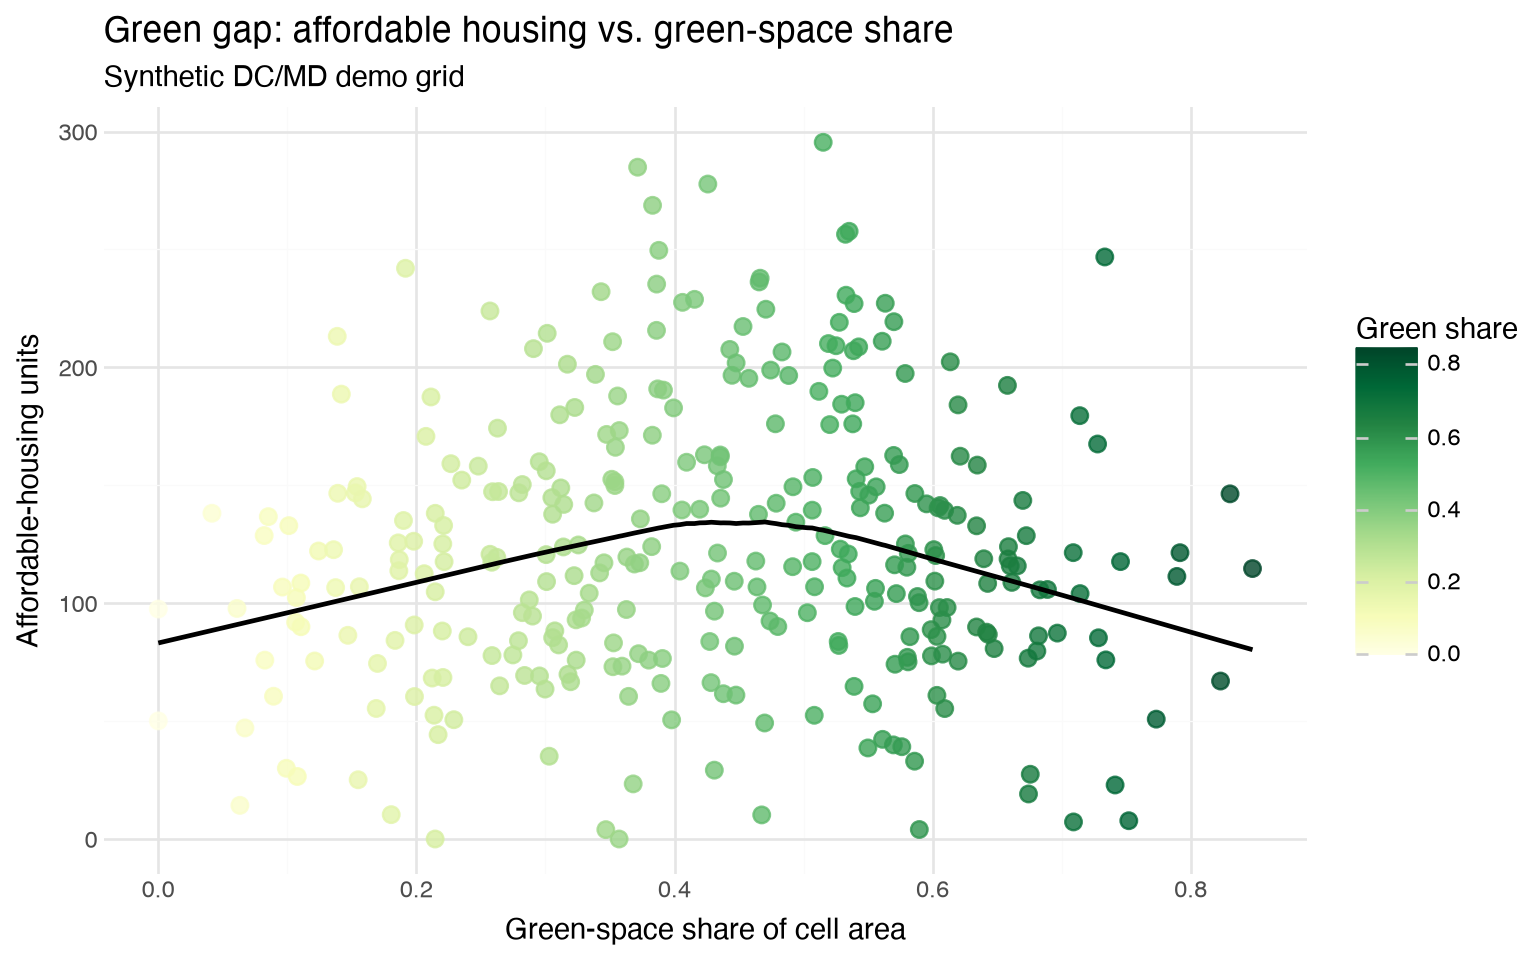

In [2]:
from plotnine import (
    ggplot, aes, geom_point, geom_smooth, labs, theme_minimal, scale_color_cmap
)

(
    ggplot(grid, aes('green_share', 'afh_units', color='green_share'))
    + geom_point(size=3, alpha=0.8)
    + geom_smooth(method='lowess', color='black', se=False)
    + scale_color_cmap(cmap_name='YlGn')
    + labs(
        title='Green gap: affordable housing vs. green-space share',
        subtitle='Synthetic DC/MD demo grid',
        x='Green-space share of cell area',
        y='Affordable-housing units',
        color='Green share',
    )
    + theme_minimal()
)

## 2. Bivariate interactive choropleth (folium)

We classify **each** variable into 3 quantile classes and cross them into a 3×3 color grid, using the helper in `greengap.bivariate`. Dark-teal cells are high on *both* green space and affordable units; pale cells are low on both.

The map is fully interactive (pan/zoom, hover tooltips) and embeds directly into the published Quarto site.

In [3]:
import folium
from greengap.bivariate import bivariate_colors, bivariate_legend_figure

grid['bi_color'] = bivariate_colors(
    grid, col_a='green_share', col_b='afh_units', palette='GnBu'
)

center = [grid.total_bounds[[1, 3]].mean(), grid.total_bounds[[0, 2]].mean()]
m = folium.Map(location=center, zoom_start=11, tiles='CartoDB positron')

folium.GeoJson(
    grid.to_json(),
    style_function=lambda feat: {
        'fillColor': feat['properties']['bi_color'],
        'color': 'white',
        'weight': 0.5,
        'fillOpacity': 0.85,
    },
    tooltip=folium.GeoJsonTooltip(
        fields=['green_share', 'afh_units'],
        aliases=['Green share:', 'AFH units:'],
        localize=True,
    ),
).add_to(m)

m

2026-07-12 20:28:10.374 | INFO     | greengap.config:<module>:11 - PROJ_ROOT path is: /Users/alibishokputov/Library/CloudStorage/Box-Box/Alibi Shokputov/03_Analysis/green-gap-affordable-housing


### Legend for the bivariate grid

The 3×3 legend reads: **→** more affordable-housing units, **↑** more green space.

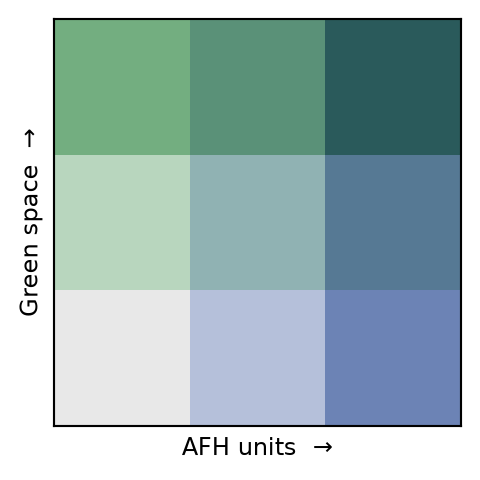

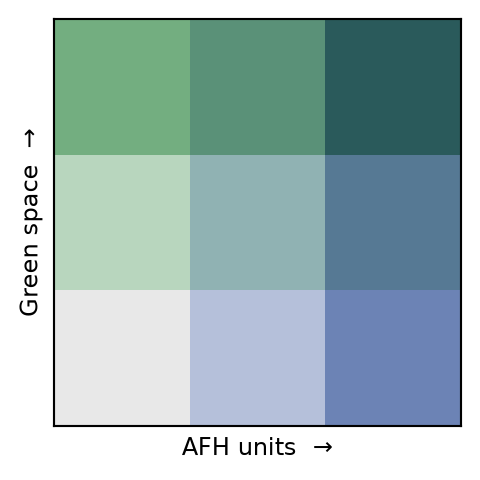

In [4]:
bivariate_legend_figure(
    palette='GnBu',
    label_a='Green space',
    label_b='AFH units',
)

## Next steps

- Replace `build_demo_grid()` with real **parcels** (`data/raw/February_2026_Parcels.zip`).
- Compute `green_share` via **`rasterstats`** zonal stats over the land-cover rasters (`dc_lc_*`, `md_lc_*`).
- Compute `afh_units` by spatially joining **LIHTC** + **NHPD** points to parcels/cells.
- Add spatial autocorrelation (`esda` Moran's I / LISA) to test whether the green gap clusters.